# Import ibt files

In [1]:
import pandas as pd
import irsdk
import matplotlib.pyplot as plt
import os
from pathlib import Path

# --- 1. EXTRAÇÃO DOS DADOS DO ARQUIVO .IBT ---
path_root = "C:/Users/to_fi/OneDrive/Documents/GitHub/Doutorado/Racing4all/Iracing/"
ibt_file = path_root + "data/formulavee_charlotte 2025 roval2025 2026-01-22 09-33-17.ibt"

# --- Configuration ---
IBT_FILES = [
    Path(ibt_file)
]

USE_IBT = True
IRSDK_AVAILABLE = True 

def load_from_ibt(ibt_path: Path) -> pd.DataFrame:
    """
    Loads binary IBT file using irsdk.
    """
    if not IRSDK_AVAILABLE:
        raise RuntimeError("irsdk is not available in this environment.")
    if not ibt_path.exists():
        raise FileNotFoundError(f".ibt file not found: {ibt_path}")
    
    ibt = irsdk.IBT()
    try:
        ibt.open(str(ibt_path))
        channels = ['SessionTime','Lap','Speed','RPM',
                    'LapDistPct','SteeringWheelAngle',
                    'LatAccel','LongAccel','Lat','Lon']
        data = {ch: ibt.get_all(ch) for ch in channels}
    except Exception as e:
        print(f"[ERROR] Failed to open {ibt_path}: {e}")
        return pd.DataFrame() 
    finally:
        ibt.close()
    return pd.DataFrame(data)

df_coords = load_from_ibt(Path(ibt_file))

In [34]:
df_coords.head()

,SessionTime,Lap,Speed,RPM,LapDistPct,SteeringWheelAngle,LatAccel,LongAccel,Lat,Lon
0,45.933332,0,0.000000,300.0,0.000000,-0.160777,0.006116,0.446031,0.000000,0.000000
1,45.949998,0,0.009311,300.0,0.065122,-0.160777,0.022690,0.087016,35.350725,-80.685287
2,45.966665,0,0.009102,300.0,0.065122,-0.160777,0.046645,0.476927,35.350725,-80.685287
3,45.983332,0,0.022123,300.0,0.065122,-0.160777,-1.332211,1.842357,35.350725,-80.685287
4,45.999998,0,0.050034,300.0,0.065121,-0.160777,-0.298518,1.157888,35.350725,-80.685287


In [2]:
df_coords['Lap'].value_counts()

Lap
1    16466
3    16284
4    16092
0    10858
2     7183
5      373
Name: count, dtype: int64

In [3]:
# --- 2. FUNÇÃO PARA FORMATAR MM:SS:ms ---
def format_lap_time(seconds):
    if seconds <= 0:
        return "00:00:000"
    minutes = int(seconds // 60)
    remainder_seconds = seconds % 60
    # {:02d} força 2 dígitos para minutos
    # {:06.3f} força 2 dígitos para segundos + ponto + 3 para milissegundos
    return f"{minutes:02d}:{remainder_seconds:06.3f}".replace('.', ':')

# --- 3. CÁLCULO DOS TEMPOS POR VOLTA ---
# Calculamos o tempo final menos o tempo inicial de cada Lap
lap_summary = df_coords.groupby('Lap')['SessionTime'].agg(['min', 'max'])
lap_summary['Duration_s'] = lap_summary['max'] - lap_summary['min']

# Aplicamos a formatação
lap_summary['Time_Formatted'] = lap_summary['Duration_s'].apply(format_lap_time)

# --- 4. EXIBIÇÃO ---
print("=== Resumo de Voltas ===")
# Removemos a volta 0 se ela for apenas a saída dos boxes (opcional)
lap_summary_filtered = lap_summary[lap_summary.index > 0]

print(lap_summary[['Time_Formatted']])

=== Resumo de Voltas ===
    Time_Formatted
Lap               
0        18:38:900
1        04:34:417
2        01:59:700
3        04:31:383
4        04:28:183
5        00:06:233


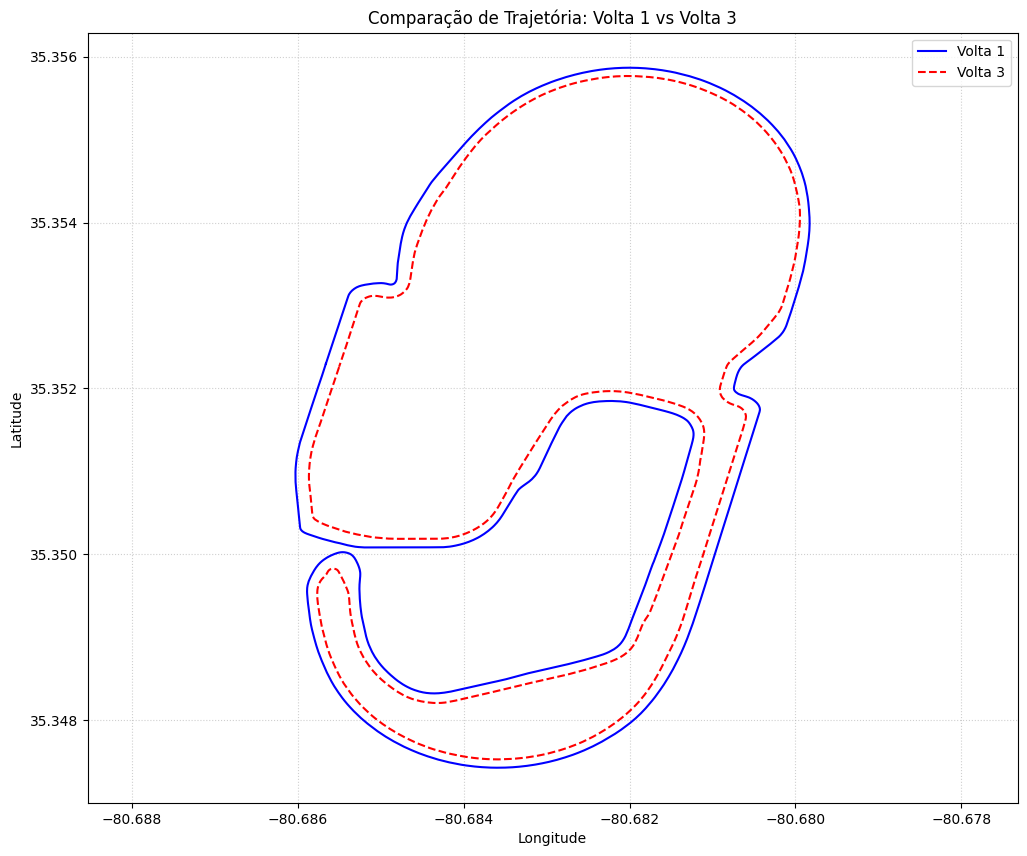

In [7]:
def plot_lap_comparison(df_input, lap_a, lap_b):
    # 1. Filtrar os dados para as duas voltas escolhidas
    data_a = df_input[df_input['Lap'] == lap_a]
    data_b = df_input[df_input['Lap'] == lap_b]

    # 2. Criar a figura
    plt.figure(figsize=(12, 10))

    # Plotar a primeira volta (ex: em Azul)
    plt.plot(data_a['Lon'], data_a['Lat'], color='blue', linewidth=1.5, label=f'Volta {lap_a}')
    
    # Plotar a segunda volta (ex: em Vermelho pontilhado para destacar diferenças)
    plt.plot(data_b['Lon'], data_b['Lat'], color='red', linewidth=1.5, linestyle='--', label=f'Volta {lap_b}')

    # 3. Ajustes de visualização do mapa
    plt.axis('equal') # Mantém a proporção real da pista
    plt.xlabel('Longitude')
    plt.ylabel('Latitude')
    plt.title(f'Comparação de Trajetória: Volta {lap_a} vs Volta {lap_b}')
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.legend()
    
    # Zoom opcional: Se quiser ver uma curva específica, você pode limitar o gráfico aqui
    # plt.xlim(lon_min, lon_max) 
    
    plt.show()

# --- Exemplo de uso ---
# Supondo que você queira comparar a volta 2 com a volta 5:
plot_lap_comparison(df_coords, lap_a=1, lap_b=3)

## Criando o banco de dados da pista



In [35]:
# Criando o banco de dados de referência de limites
# Filtramos as voltas e resetamos o index para facilitar a manipulação
# Usamos .copy() para evitar avisos de SettingWithCopyWarning do Pandas
df_limites_esq = df_coords[df_coords['Lap'] == 1].copy()
df_limites_dir = df_coords[df_coords['Lap'] == 3].copy()

# Dica de PhD: Para comparar pontos, às vezes é útil interpolar esses limites 
# para que ambos tenham o mesmo número de pontos (ex: 5000 pontos cada)

## Gerando a linha central média entre os limites superiores e inferiores

In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

def generate_centerline_by_pct(df_esq, df_dir, num_points=5000):
    # 1. Criar o eixo comum de 0% a 100% da volta
    # Isso garante que compararemos pontos na mesma posição do traçado
    common_pct = np.linspace(0, 1, num_points)

    # 2. Interpolar os muros baseando-se na variável nativa LapDistPct
    # Precisamos garantir que os dados estejam ordenados pela distância
    df_esq = df_esq.sort_values('LapDistPct')
    df_dir = df_dir.sort_values('LapDistPct')

    # Funções de interpolação para o Muro Esquerdo
    interp_lat_esq = interp1d(df_esq['LapDistPct'], df_esq['Lat'], kind='linear', fill_value="extrapolate")
    interp_lon_esq = interp1d(df_esq['LapDistPct'], df_esq['Lon'], kind='linear', fill_value="extrapolate")
    
    # Funções de interpolação para o Muro Direito
    interp_lat_dir = interp1d(df_dir['LapDistPct'], df_dir['Lat'], kind='linear', fill_value="extrapolate")
    interp_lon_dir = interp1d(df_dir['LapDistPct'], df_dir['Lon'], kind='linear', fill_value="extrapolate")

    # 3. Gerar coordenadas alinhadas e calcular a média (Centerline)
    center_lat = (interp_lat_esq(common_pct) + interp_lat_dir(common_pct)) / 2
    center_lon = (interp_lon_esq(common_pct) + interp_lon_dir(common_pct)) / 2

    return pd.DataFrame({
        'LapDistPct': common_pct,
        'Lat': center_lat, 
        'Lon': center_lon
    })

# --- Execução ---
# df_limites_esq e df_limites_dir devem conter a coluna 'LapDistPct' extraída do .ibt
df_centerline = generate_centerline_by_pct(df_limites_esq, df_limites_dir)

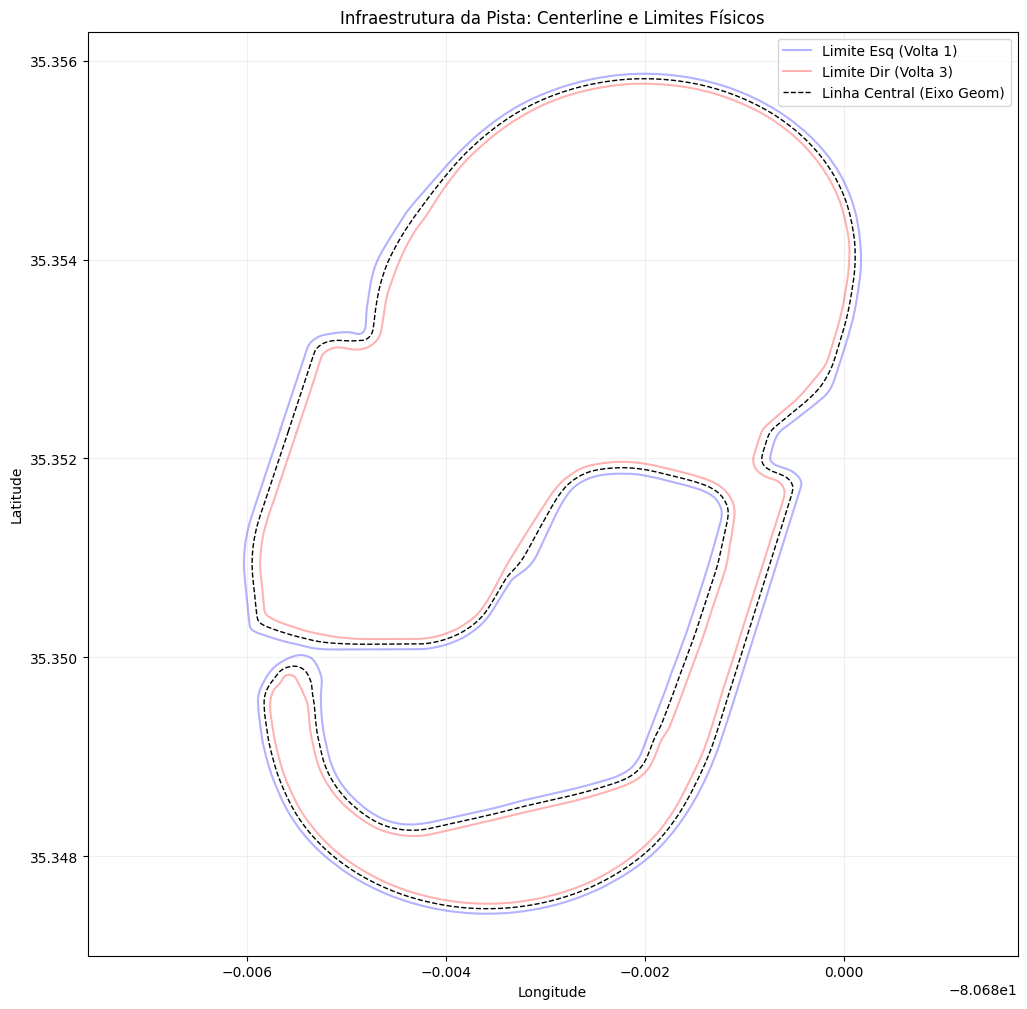

In [ ]:
def plot_track_infrastructure(df_esq, df_dir, df_center):
    plt.figure(figsize=(12, 12))

    # Limites (Muros)
    plt.plot(df_esq['Lon'], df_esq['Lat'], color='blue', alpha=0.3, label='Limite Esq (Volta 1)')
    plt.plot(df_dir['Lon'], df_dir['Lat'], color='red', alpha=0.3, label='Limite Dir (Volta 3)')

    # Linha Central (Centerline)
    plt.plot(df_center['Lon'], df_center['Lat'], color='black', 
             linestyle='--', linewidth=1, label='Linha Central (Eixo Geom)')

    plt.axis('equal')
    plt.title('Infraestrutura da Pista: Centerline e Limites Físicos')
    plt.xlabel('Longitude')
    plt.ylabel('Latitude')
    plt.legend()
    plt.grid(True, alpha=0.2)
    plt.show()

plot_track_infrastructure(df_limites_esq, df_limites_dir, df_centerline)

## 1. Conversão de Coordenadas para Metros

Como a Terra não é plana, um grau de Latitude não tem o mesmo comprimento de um grau de Longitude. Para Charlotte Motor Speedway ($\approx 35.35^\circ$ N), utilizaremos os seguintes fatores de conversão: 

$1^\circ \text{ de Latitude} \approx 110.940 \text{ metros}$

$1^\circ \text{ de Longitude} \approx 90.795 \text{ metros}$ (ajustado pelo cosseno da latitude local)

In [46]:
def calculate_n_meters(df_fast, df_centerline):
    # 1. Interpolar a Centerline permitindo pequena extrapolação
    # Isso evita o erro se o LapDistPct for levemente menor que 0 ou maior que 1
    interp_lat = interp1d(df_centerline['LapDistPct'], df_centerline['Lat'], 
                          kind='linear', bounds_error=False, fill_value="extrapolate")
    interp_lon = interp1d(df_centerline['LapDistPct'], df_centerline['Lon'], 
                          kind='linear', bounds_error=False, fill_value="extrapolate")
    
    # Referencial da linha central no espaço do piloto
    lat_c = interp_lat(df_fast['LapDistPct'])
    lon_c = interp_lon(df_fast['LapDistPct'])
    
    # 2. Calcular as diferenças em graus
    d_lat = df_fast['Lat'] - lat_c
    d_lon = df_fast['Lon'] - lon_c
    
    # 3. Converter para metros (Fatores de Charlotte Motor Speedway)
    d_lat_m = d_lat * 110940
    d_lon_m = d_lon * 90795
    
    # 4. Calcular a magnitude do desvio lateral (n) em metros
    # O sinal indica se o piloto está à esquerda ou direita da centerline
    n = np.sqrt(d_lat_m**2 + d_lon_m**2) * np.sign(d_lon) 
    
    return n

# --- Execução Corrigida para a Volta 2 ---
df_volta_2 = df_coords[df_coords['Lap'] == 2].copy()
n_meters = calculate_n_meters(df_volta_2, df_centerline)

print(f"Desvio lateral calculado para a Volta 2. Desvio máximo: {np.max(np.abs(n_meters)):.2f} metros.")

Desvio lateral calculado para a Volta 2. Desvio máximo: 9.58 metros.


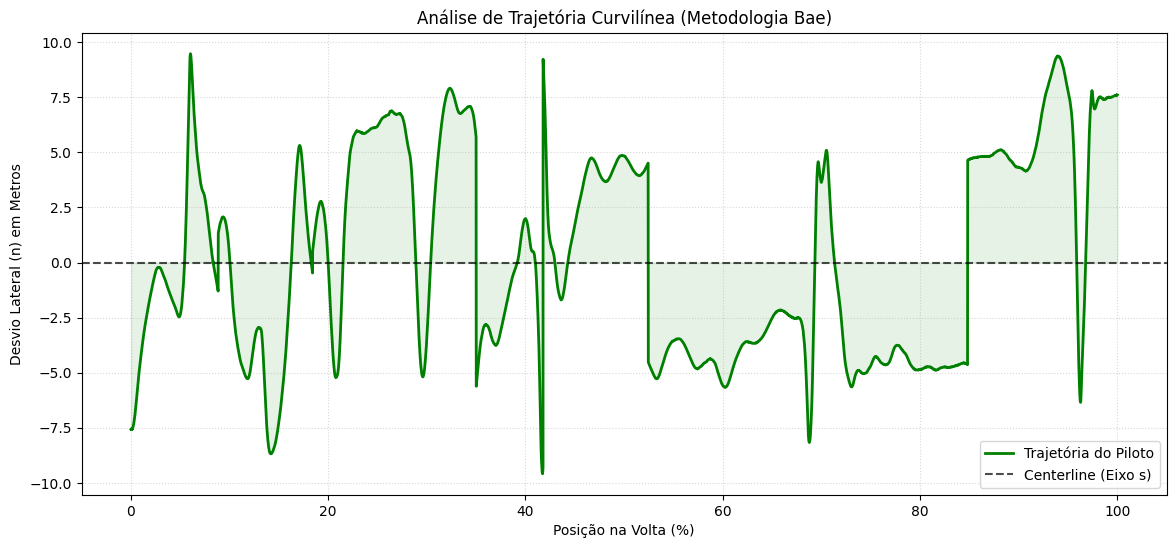

In [47]:
plt.figure(figsize=(14, 6))

# Plotar o desvio lateral
plt.plot(df_volta_5['LapDistPct'] * 100, n_meters, color='green', linewidth=2, label='Trajetória do Piloto')

# Linha Central (Referência Zero)
plt.axhline(0, color='black', linestyle='--', alpha=0.7, label='Centerline (Eixo s)')

# Estética do gráfico
plt.fill_between(df_volta_5['LapDistPct'] * 100, n_meters, color='green', alpha=0.1)
plt.xlabel('Posição na Volta (%)')
plt.ylabel('Desvio Lateral (n) em Metros')
plt.title('Análise de Trajetória Curvilínea (Metodologia Bae)')
plt.grid(True, which='both', linestyle=':', alpha=0.5)
plt.legend()

plt.show()

In [49]:
import matplotlib.pyplot as plt
from ipywidgets import interact, widgets

def plot_dynamic_analysis(index):
    # Criar subplots: cima (desvio) e baixo (mapa)
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 12), gridspec_kw={'height_ratios': [1, 2]})
    
    # ACESSO POSICIONAL (.iloc): essencial para dados filtrados
    current_pct = df_volta_2['LapDistPct'].iloc[index]
    current_n = n_meters.iloc[index]
    
    # --- SUBPLOT 1: Gráfico de Desvio Lateral (n) ---
    ax1.plot(df_volta_2['LapDistPct'] * 100, n_meters, color='blue', alpha=0.5)
    ax1.axhline(0, color='black', linestyle='--', alpha=0.3)
    
    # Destaque do ponto atual
    ax1.scatter(current_pct * 100, current_n, color='red', s=50, zorder=5)
    ax1.set_ylabel('Desvio Lateral n (Metros)')
    ax1.set_title(f'Análise Curvilínea: {current_n:.2f}m em {current_pct*100:.1f}% da volta')
    ax1.grid(True, alpha=0.3)

    # --- SUBPLOT 2: Mapa da Pista ---
    # Referências (Cinza)
    ax2.plot(df_limites_esq['Lon'], df_limites_esq['Lat'], 'gray', alpha=0.2)
    ax2.plot(df_limites_dir['Lon'], df_limites_dir['Lat'], 'gray', alpha=0.2)
    ax2.plot(df_centerline['Lon'], df_centerline['Lat'], 'k--', alpha=0.1)
    
    # Volta do Piloto (Azul)
    ax2.plot(df_volta_2['Lon'], df_volta_2['Lat'], color='blue', alpha=0.3)
    
    # Posição atual do carro no mapa
    current_lon = df_volta_2['Lon'].iloc[index]
    current_lat = df_volta_2['Lat'].iloc[index]
    ax2.scatter(current_lon, current_lat, color='red', s=100, edgecolors='black', label='Carro')
    
    ax2.set_aspect('equal')
    ax2.set_xlabel('Longitude')
    ax2.set_ylabel('Latitude')
    ax2.legend()

    plt.tight_layout()
    plt.show()

# Slider dinâmico
interact(plot_dynamic_analysis, 
         index=widgets.IntSlider(min=0, max=len(df_volta_2)-1, step=1, value=0, description='Frame:'))

interactive(children=(IntSlider(value=0, description='Frame:', max=7182), Output()), _dom_classes=('widget-int…

<function __main__.plot_dynamic_analysis(index)>

# Testando com o OpenStreetMap



In [ ]:
%pip install osmnx


C:\Users\to_fi\AppData\Local\Temp\ipykernel_4708\939400093.py:31: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  for x, y, label in zip(roval_final.geometry.centroid.x, roval_final.geometry.centroid.y, roval_final['name']):


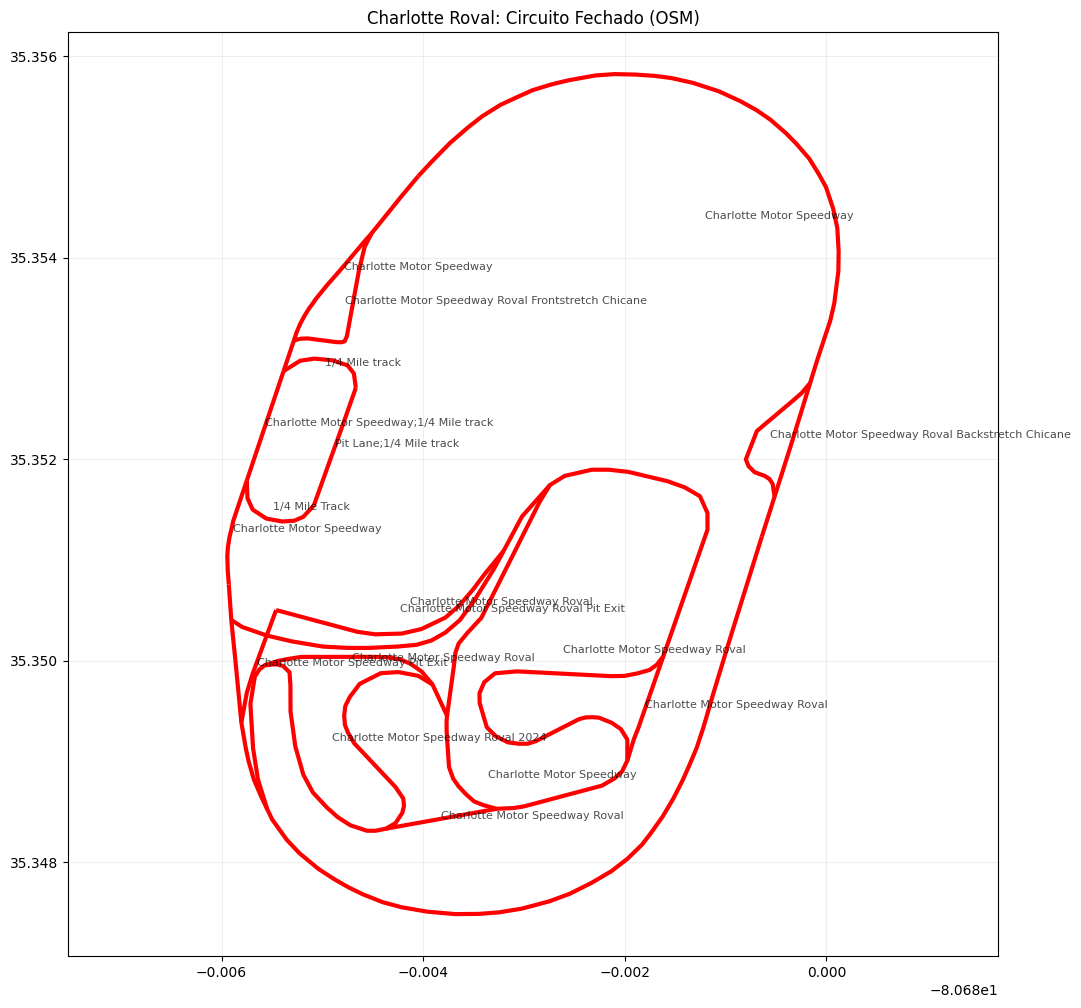

Segmentos incluídos no banco de dados:
['Charlotte Motor Speedway' 'Charlotte Motor Speedway Roval 2024'
 'Charlotte Motor Speedway Roval' '1/4 Mile Track'
 'Charlotte Motor Speedway Pit Exit' 'Pit Lane;1/4 Mile track'
 '1/4 Mile track' 'Charlotte Motor Speedway;1/4 Mile track'
 'Charlotte Motor Speedway Roval Frontstretch Chicane'
 'Charlotte Motor Speedway Roval Backstretch Chicane'
 'Charlotte Motor Speedway Roval Pit Exit']


In [15]:
import osmnx as ox
import matplotlib.pyplot as plt

# 1. Configuração de busca focada no centro da pista
# Coordenadas aproximadas do centro da tri-oval
center_point = (35.3515, -80.6827)
tags = {"highway": "raceway"}

# 2. Download dos dados
# Reduzi o raio para 800m para evitar pegar o Dragway mesmo sem filtros
track_features = ox.features_from_point(center_point, tags=tags, dist=800)
all_lines = track_features[track_features.geometry.type == 'LineString'].copy()

# 3. MÁSCARA DE FILTRAGEM AMPLIADA
# Incluímos '1/4' para pegar a reta que você identificou
# Incluímos qualquer variação de 'Charlotte Motor Speedway'
include_mask = all_lines['name'].str.contains('Roval|1/4|Charlotte Motor Speedway', na=False, case=False)

# Mantemos a exclusão de pistas de terra ou kart que fiquem no raio
exclude_mask = all_lines['name'].str.contains('Dirt|Kart', na=False, case=False)

roval_final = all_lines[include_mask & ~exclude_mask]

# 4. Plotagem com Verificação de Nomes
fig, ax = plt.subplots(figsize=(12, 12))

# Plotamos o que sobrou (o traçado completo)
roval_final.plot(ax=ax, color='red', linewidth=3, label='Traçado Roval Completo')

# Adicionamos os nomes nos segmentos para você conferir se falta algo
for x, y, label in zip(roval_final.geometry.centroid.x, roval_final.geometry.centroid.y, roval_final['name']):
    ax.text(x, y, label, fontsize=8, alpha=0.7)

plt.title("Charlotte Roval: Circuito Fechado (OSM)")
plt.axis('equal')
plt.grid(True, alpha=0.2)
plt.show()

# 5. Lista de nomes incluídos (para seu controle de dados)
print("Segmentos incluídos no banco de dados:")
print(roval_final['name'].unique())

In [16]:
# Extrair todos os pontos (nós) do traçado filtrado para uma lista de coordenadas
coords_list = []
for line in roval_final.geometry:
    coords_list.extend(list(line.coords))

# Criar um DataFrame de referência para sua investigação
df_osm_reference = pd.DataFrame(coords_list, columns=['Lon', 'Lat'])
print(f"Banco de dados de referência criado com {len(df_osm_reference)} pontos.")

Banco de dados de referência criado com 296 pontos.


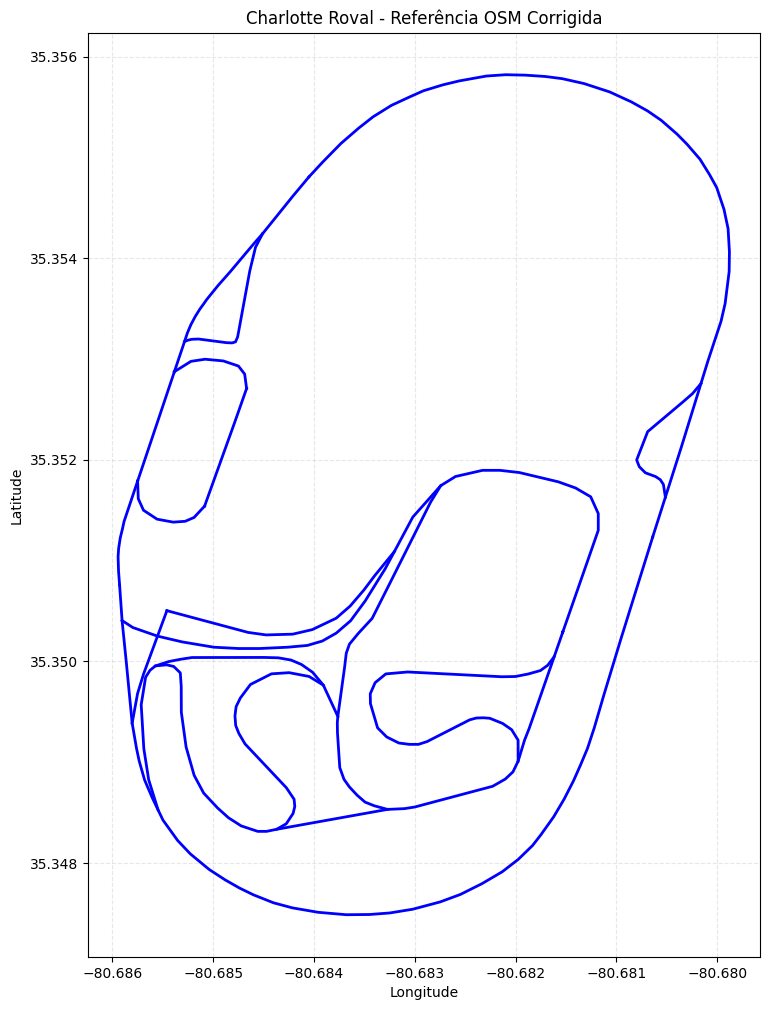

In [18]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 12))

# Em vez de extrair os pontos para uma lista, plote diretamente do GeoDataFrame
# Isso mantém as conexões apenas dentro de cada segmento original
for geom in roval_final.geometry:
    x, y = geom.xy
    ax.plot(x, y, color='blue', linewidth=2)

# Adicionar os pontos (opcional, para ver a densidade de dados)
# ax.scatter(df_osm_reference['Lon'], df_osm_reference['Lat'], color='red', s=5, alpha=0.5)

ax.set_aspect('equal')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('Charlotte Roval - Referência OSM Corrigida')
plt.grid(True, linestyle='--', alpha=0.3)
plt.show()